In [1]:
import os
import numpy as np
import scipy as sp
import pandas as pd
from datetime import date
import marineHeatWaves as mhw
import netCDF4 as nc
import datetime
import matplotlib.pyplot as plt
from tqdm import notebook
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.backends.backend_agg import FigureCanvasAgg
import PIL.Image as Image
from scipy.stats import pearsonr
time=pd.date_range('2021-7-1','2021-9-30')

In [2]:

## mld
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(mld,dat)))
    del pool
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map,a)))
    del pool
    return ans
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

# Q
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')[time2021ind]/3600#ShortwaveRadiation
strs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')[time2021ind]/3600#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')[time2021ind]/3600#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')[time2021ind]/3600#SensibleHeatFlux
del times,time2021ind
Q_net=ssrs_2021+strs_2021+slhfs_2021+sshfs_2021
Q_z=ssrs_2021*(0.58*np.exp(-1*mld2021a1/0.35)+0.42*np.exp(-1*mld2021a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021a1)*24*3600

#MLTT
# T_m
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
tms=np.array(list(pool.map(onetime2,thetaos2020a1)))
del pool
mltt=tms[1:,:,:]-tms[:-1,:,:]
#np.save('12_10mltt.npy',mltt)

# HADV
us2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_2021.npy")*3600*24
vs2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/vo_2021.npy")*3600*24
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,dat)))
    del pool
    #ans=np.array(list(map(list_map2,dat)))
    return ans
def ms(dat):
    global thetaos2020a1
    pool = ProcessPoolExecutor(max_workers=3)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos2020a1]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(us2020a1)
vm=ms(vs2020a1)
dx=np.array([(tms[:,i,1:]-tms[:,i,:-1])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms[:,1:,:]-tms[:,:-1,:])/(111e3/4)
hadv=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

# OVMIX
W_e=mld2021a1[1:,:,:]-mld2021a1[:-1,:,:]
def th(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return dat[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map3(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(th,dat)))
    del pool
    return ans
def onetime3(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map3,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
ths=np.array(list(pool.map(onetime3,thetaos2020a1)))
del pool
#mltt=tms[1:,:,:]-tms[:-1,:,:]
def dtdz(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return (dat[dat[0]-0.8-dat>0][0]-dat[dat[0]-0.8-dat<0][-1])/(-1*(depth[dat[0]-0.8-dat>0][0])-(-1)*(depth[dat[0]-0.8-dat<0][-1]))
    else:
        return np.nan
def list_map4(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(dtdz,dat)))
    del pool
    return ans
def onetime4(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map4,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
dtdz=np.array(list(pool.map(onetime4,thetaos2020a1)))
del pool
ovmix1=(-1/mld2021a1*(tms-ths))
ovmix1=ovmix1[:-1,:,:]*W_e
ovmix2=-1/mld2021a1*(1e-4)*24*3600*dtdz
ovmix=ovmix1+ovmix2[:-1,:,:]
res1v1=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]-ovmix[:,:-1,:-1]
res2v1=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]

lat_4 range:50.00~35.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


In [3]:

## mld
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(mld,dat)))
    del pool
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map,a)))
    del pool
    return ans
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

# Q
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')[time2021ind]/3600#ShortwaveRadiation
strs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')[time2021ind]/3600#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')[time2021ind]/3600#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')[time2021ind]/3600#SensibleHeatFlux
del times,time2021ind
Q_net=ssrs_2021+strs_2021+slhfs_2021+sshfs_2021
Q_z=ssrs_2021*(0.58*np.exp(-1*mld2021a1/0.35)+0.42*np.exp(-1*mld2021a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021a1)*24*3600

#MLTT
# T_m
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
tms=np.array(list(pool.map(onetime2,thetaos2020a1)))
del pool
mltt=tms[:-1,:,:]-tms[1:,:,:]
#np.save('12_10mltt.npy',mltt)

# HADV
us2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_2021.npy")*3600*24
vs2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/vo_2021.npy")*3600*24
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,dat)))
    del pool
    #ans=np.array(list(map(list_map2,dat)))
    return ans
def ms(dat):
    global thetaos2020a1
    pool = ProcessPoolExecutor(max_workers=3)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos2020a1]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(us2020a1)
vm=ms(vs2020a1)
dx=np.array([(tms[:,i,1:]-tms[:,i,:-1])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms[:,1:,:]-tms[:,:-1,:])/(111e3/4)
hadv=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

# OVMIX
W_e=mld2021a1[1:,:,:]-mld2021a1[:-1,:,:]
def th(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return dat[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map3(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(th,dat)))
    del pool
    return ans
def onetime3(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map3,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
ths=np.array(list(pool.map(onetime3,thetaos2020a1)))
del pool
#mltt=tms[1:,:,:]-tms[:-1,:,:]
def dtdz(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return (dat[dat[0]-0.8-dat>0][0]-dat[dat[0]-0.8-dat<0][-1])/(-1*(depth[dat[0]-0.8-dat>0][0])-(-1)*(depth[dat[0]-0.8-dat<0][-1]))
    else:
        return np.nan
def list_map4(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(dtdz,dat)))
    del pool
    return ans
def onetime4(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map4,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
dtdz=np.array(list(pool.map(onetime4,thetaos2020a1)))
del pool
ovmix1=(-1/mld2021a1*(tms-ths))
ovmix1=ovmix1[:-1,:,:]*W_e
ovmix2=-1/mld2021a1*(1e-4)*24*3600*dtdz
ovmix=ovmix1+ovmix2[:-1,:,:]
res1v2=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]-ovmix[:,:-1,:-1]
res2v2=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]

lat_4 range:50.00~35.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


In [4]:

## mld
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(mld,dat)))
    del pool
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map,a)))
    del pool
    return ans
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

# Q
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')[time2021ind]/3600#ShortwaveRadiation
strs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')[time2021ind]/3600#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')[time2021ind]/3600#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')[time2021ind]/3600#SensibleHeatFlux
del times,time2021ind
Q_net=ssrs_2021+strs_2021+slhfs_2021+sshfs_2021
Q_z=ssrs_2021*(0.58*np.exp(-1*mld2021a1/0.35)+0.42*np.exp(-1*mld2021a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021a1)*24*3600

#MLTT
# T_m
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
tms=np.array(list(pool.map(onetime2,thetaos2020a1)))
del pool
mltt=tms[1:,:,:]-tms[:-1,:,:]
#np.save('12_10mltt.npy',mltt)

# HADV
us2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_2021.npy")*3600*24
vs2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/vo_2021.npy")*3600*24
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,dat)))
    del pool
    #ans=np.array(list(map(list_map2,dat)))
    return ans
def ms(dat):
    global thetaos2020a1
    pool = ProcessPoolExecutor(max_workers=3)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos2020a1]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(us2020a1)
vm=ms(vs2020a1)
dx=np.array([tms[:,i,:-1]-(tms[:,i,1:])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms[:,:-1,:]-tms[:,1:,:])/(111e3/4)
hadv=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

# OVMIX
W_e=mld2021a1[1:,:,:]-mld2021a1[:-1,:,:]
def th(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return dat[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map3(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(th,dat)))
    del pool
    return ans
def onetime3(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map3,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
ths=np.array(list(pool.map(onetime3,thetaos2020a1)))
del pool
#mltt=tms[1:,:,:]-tms[:-1,:,:]
def dtdz(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return (dat[dat[0]-0.8-dat>0][0]-dat[dat[0]-0.8-dat<0][-1])/(-1*(depth[dat[0]-0.8-dat>0][0])-(-1)*(depth[dat[0]-0.8-dat<0][-1]))
    else:
        return np.nan
def list_map4(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(dtdz,dat)))
    del pool
    return ans
def onetime4(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map4,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
dtdz=np.array(list(pool.map(onetime4,thetaos2020a1)))
del pool
ovmix1=(-1/mld2021a1*(tms-ths))
ovmix1=ovmix1[:-1,:,:]*W_e
ovmix2=-1/mld2021a1*(1e-4)*24*3600*dtdz
ovmix=ovmix1+ovmix2[:-1,:,:]
res1v3=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]-ovmix[:,:-1,:-1]
res2v3=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]

lat_4 range:50.00~35.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


In [5]:

## mld
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def mld(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return depth[dat[0]-0.8-dat>0][0]
    else:
        return np.nan
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(mld,dat)))
    del pool
    return ans
def onetime(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map,a)))
    del pool
    return ans
thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
mld2021a1=np.array(list(pool.map(onetime,thetaos2020a1)))
del pool

# Q
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')[time2021ind]/3600#ShortwaveRadiation
strs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')[time2021ind]/3600#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')[time2021ind]/3600#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')[time2021ind]/3600#SensibleHeatFlux
del times,time2021ind
Q_net=ssrs_2021+strs_2021+slhfs_2021+sshfs_2021
Q_z=ssrs_2021*(0.58*np.exp(-1*mld2021a1/0.35)+0.42*np.exp(-1*mld2021a1/23))
Q=(Q_net-Q_z)/(1.024*1e3*3850*mld2021a1)*24*3600

#MLTT
# T_m
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return np.nanmean(dat[dat[0]-0.8-dat<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
tms=np.array(list(pool.map(onetime2,thetaos2020a1)))
del pool
mltt=tms[1:,:,:]-tms[:-1,:,:]
#np.save('12_10mltt.npy',mltt)

# HADV
us2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/uos_2021.npy")*3600*24
vs2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/vo_2021.npy")*3600*24
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
lat_4_ind=(lat_4>=35)&(lat_4<=50)
lon_4_ind=(lon_4>=195)&(lon_4<=230)
lat_4=lat_4[lat_4_ind]
lon_4=lon_4[lon_4_ind]
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
depth=np.load('/lustre/home/yuhanxue/data/GLORYS/area1_re/depth.npy')
def tm(dat):
    global depth
    if dat[1,0]-0.8>dat[1,-1]:
        return np.nanmean(dat[0,dat[1,0]-0.8-dat[1,:]<0])
    else:
        return np.nan
def list_map2(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(tm,dat)))
    del pool
    return ans
def onetime2(dat):
    #a=np.swapaxes(dat,0,1)
    #a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map2,dat)))
    del pool
    #ans=np.array(list(map(list_map2,dat)))
    return ans
def ms(dat):
    global thetaos2020a1
    pool = ProcessPoolExecutor(max_workers=3)
    a=np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.swapaxes(np.array([dat,thetaos2020a1]),0,1),2,3),1,2),3,4),2,3)
    ans=np.array(list(pool.map(onetime2,a)))
    del pool
    return ans
um=ms(us2020a1)
vm=ms(vs2020a1)
dx=np.array([(tms[:,i,1:]-tms[:,i,:-1])/(111e3/4*np.cos(lat_4[i]/180*np.pi)) for i in range(0,61)])
dx=np.swapaxes(dx,0,1)
dy=(tms[:,1:,:]-tms[:,:-1,:])/(111e3/4)
hadv=(um[:,:-1,:-1]*dx[:,:-1,:]+um[:,:-1,:-1]*dy[:,:,:-1])*-1

# OVMIX
W_e=mld2021a1[1:,:,:]-mld2021a1[:-1,:,:]
def th(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return dat[dat[0]-0.8-dat<0][-1]
    else:
        return np.nan
def list_map3(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(th,dat)))
    del pool
    return ans
def onetime3(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map3,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
ths=np.array(list(pool.map(onetime3,thetaos2020a1)))
del pool
#mltt=tms[1:,:,:]-tms[:-1,:,:]
def dtdz(dat):
    global depth
    if dat[0]-0.8>dat[-1]:
        return (dat[dat[0]-0.8-dat>0][0]-dat[dat[0]-0.8-dat<0][-1])/(-1*(depth[dat[0]-0.8-dat>0][0])-(-1)*(depth[dat[0]-0.8-dat<0][-1]))
    else:
        return np.nan
def list_map4(dat):
    pool = ProcessPoolExecutor(max_workers=6)
    ans=np.array(list(pool.map(dtdz,dat)))
    del pool
    return ans
def onetime4(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=3)
    ans=np.array(list(pool.map(list_map4,a)))
    del pool
    return ans
# thetaos2020a1=np.load("/lustre/home/yuhanxue/data/GLORYS/area1_re/thetaos_2021.npy")
pool = ProcessPoolExecutor(max_workers=3)
dtdz=np.array(list(pool.map(onetime4,thetaos2020a1)))
del pool
ovmix1=(-1/mld2021a1*(tms-ths))
ovmix1=ovmix1[:-1,:,:]*W_e
ovmix2=-1/mld2021a1*(1e-4)*24*3600*dtdz
ovmix=ovmix1+ovmix2[:-1,:,:]
res1v4=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]-ovmix[:,:-1,:-1]
res2v4=mltt[:,:-1,:-1]-Q[:-1,:-1,:-1]-hadv[:-1,:,:]

lat_4 range:50.00~35.00 | freq:0.25
lon_4 range:195.00~230.00 | freq:0.25


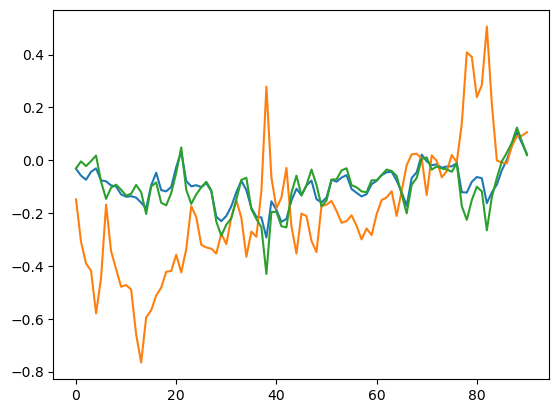

In [9]:
plt.plot(np.nanmean(np.nanmean(res1v1,axis=-1),axis=-1))
plt.plot(np.nanmean(np.nanmean(res1v2,axis=-1),axis=-1))
#plt.plot(np.nanmean(np.nanmean(res1v3,axis=-1),axis=-1))
plt.plot(np.nanmean(np.nanmean(res1v4,axis=-1),axis=-1))